# Matplotlib Foundations & Figure Architecture (5+ Years Interview Guide)
Exhaustive revision guide with dedicated separate cells for figure canvas initialization, line plots, scatter plots, bar charts, histograms, error bars, axis styling, and static export on raw_transactions.csv.

### Key 5-Year Interview Concepts Covered:
- **Canvas Initialization**: Dedicated separate cells for `fig, ax = plt.subplots(figsize=(8, 5))` and `fig = plt.figure()`.
- **Core Line & Scatter Plotting**: Dedicated separate cells for `ax.plot(x, y, label=...)` and `ax.scatter(x, y, c=...)`.
- **Categorical & Distributional Plotting**: Dedicated separate cells for `ax.bar(x, height)`, `ax.hist(data, bins=...)`, and `ax.errorbar(x, y, yerr=...)`.
- **Axis Tuning**: Dedicated separate cells for `ax.set_xlabel()`, `ax.set_ylabel()`, `ax.set_title()`, `ax.set_xlim()`, `ax.set_ylim()`, `ax.grid(True)`, and `ax.legend()`.
- **Output Persistence**: Dedicated separate cell for `fig.savefig('plot.png', dpi=300, bbox_inches='tight')`.

This interactive revision guide uses `data/raw_transactions.csv` with 1-to-1 atomic method cells and rich inline visual outputs.

In [1]:
# Setup imports & dataset loading from raw_transactions.csv
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import sys

# Configure visual aesthetics
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 10

csv_path = 'data/raw_transactions.csv' if os.path.exists('data/raw_transactions.csv') else '../data/raw_transactions.csv'
df = pd.read_csv(csv_path)
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='mixed', errors='coerce')
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')
df['account_age_months'] = pd.to_numeric(df['account_age_months'], errors='coerce')
df['is_fraud'] = pd.to_numeric(df['is_fraud'], errors='coerce').fillna(0).astype(int)
df = df.dropna(subset=['transaction_amount', 'transaction_date']).reset_index(drop=True)

print(f"Loaded {len(df)} cleaned transaction records from {csv_path}")
print(df.head(2))

Loaded 14262 cleaned transaction records from data/raw_transactions.csv
  transaction_id customer_id merchant_id  ...  transaction_date region is_fraud
0       TX110686      C82845       M2697  ...        2025-07-06  North        0
1       TX107170      C85674       M3868  ...        2025-10-05   East        0

[2 rows x 11 columns]


### Canvas Initialization: `fig, ax = plt.subplots()`
**Explanation**: Creates Figure and Axes objects representing the top-level window container and coordinate plane.

**Syntax**: `fig, ax = plt.subplots(figsize=(8, 4))`

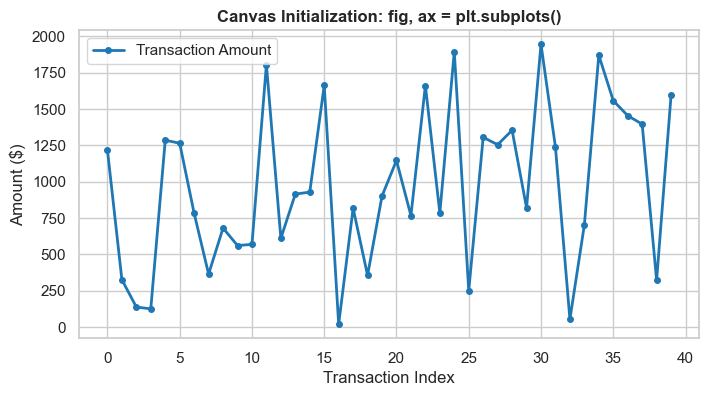

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df['transaction_amount'].head(40).values, color='#1f77b4', lw=2, marker='o', markersize=4, label='Transaction Amount')
ax.set_title('Canvas Initialization: fig, ax = plt.subplots()', fontsize=12, fontweight='bold')
ax.set_xlabel('Transaction Index')
ax.set_ylabel('Amount ($)')
ax.legend()
plt.show()

### Figure Container: `fig = plt.figure()`
**Explanation**: Top-level window container managing canvas drawing state and manual coordinate axes.

**Syntax**: `fig = plt.figure(figsize=(8, 4))`

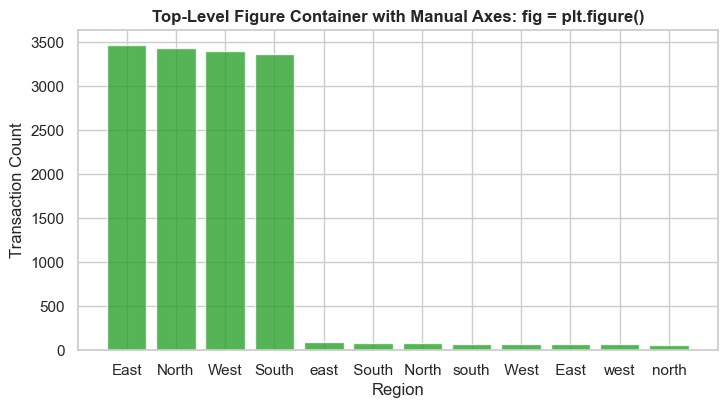

In [3]:
fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # [left, bottom, width, height]
ax1.bar(df['region'].value_counts().index, df['region'].value_counts().values, color='#2ca02c', alpha=0.8)
ax1.set_title('Top-Level Figure Container with Manual Axes: fig = plt.figure()', fontsize=12, fontweight='bold')
ax1.set_xlabel('Region')
ax1.set_ylabel('Transaction Count')
plt.show()

### Line Plotting: `ax.plot(x, y, label=...)`
**Explanation**: Renders 2D connected line series showing time-series progression of daily transaction volume.

**Syntax**: `ax.plot(dates, amounts, label='Daily Spend', color='royalblue')`

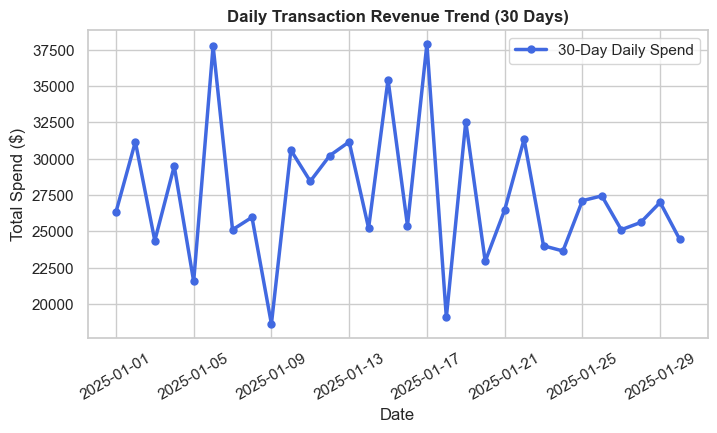

In [4]:
daily_trend = df.set_index('transaction_date').resample('D')['transaction_amount'].sum().head(30)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(daily_trend.index, daily_trend.values, label='30-Day Daily Spend', color='royalblue', lw=2.5, marker='o', markersize=5)
ax.set_title('Daily Transaction Revenue Trend (30 Days)', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Spend ($)')
ax.legend()
plt.xticks(rotation=30)
plt.show()

### Scatter Plotting: `ax.scatter(x, y, c=...)`
**Explanation**: Renders 2D coordinate points displaying correlation between account age and transaction amount.

**Syntax**: `ax.scatter(df['account_age_months'], df['transaction_amount'], c=df['is_fraud'])`

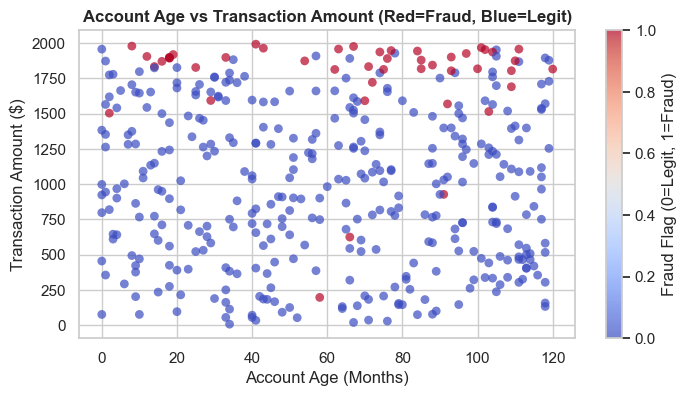

In [5]:
sample = df.head(400)
fig, ax = plt.subplots(figsize=(8, 4))
scatter = ax.scatter(sample['account_age_months'], sample['transaction_amount'], c=sample['is_fraud'], cmap='coolwarm', alpha=0.7, s=40, edgecolors='none')
ax.set_title('Account Age vs Transaction Amount (Red=Fraud, Blue=Legit)', fontsize=12, fontweight='bold')
ax.set_xlabel('Account Age (Months)')
ax.set_ylabel('Transaction Amount ($)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Fraud Flag (0=Legit, 1=Fraud)')
plt.show()

### Bar Charting: `ax.bar(x, height)`
**Explanation**: Plots categorical aggregations comparing total transaction volume across regions.

**Syntax**: `ax.bar(regions, spend, color='teal')`

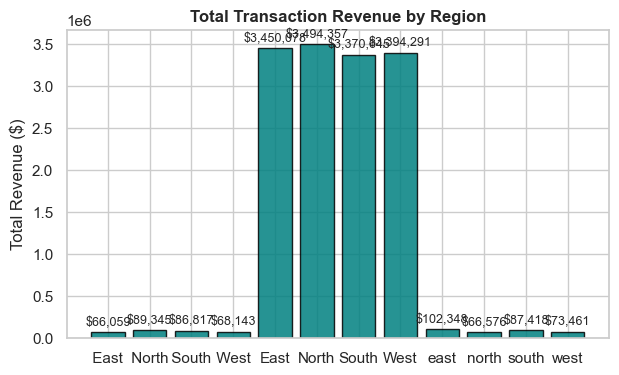

In [6]:
reg_spend = df.groupby('region')['transaction_amount'].sum()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(reg_spend.index, reg_spend.values, color='teal', edgecolor='black', alpha=0.85)
ax.set_title('Total Transaction Revenue by Region', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Revenue ($)')
ax.bar_label(bars, fmt='${:,.0f}', padding=3, fontsize=9)
plt.show()

### Histogram Distribution: `ax.hist(data, bins=...)`
**Explanation**: Bifurcates continuous transaction amounts into discrete bins displaying frequency density.

**Syntax**: `ax.hist(df['transaction_amount'], bins=30, color='purple')`

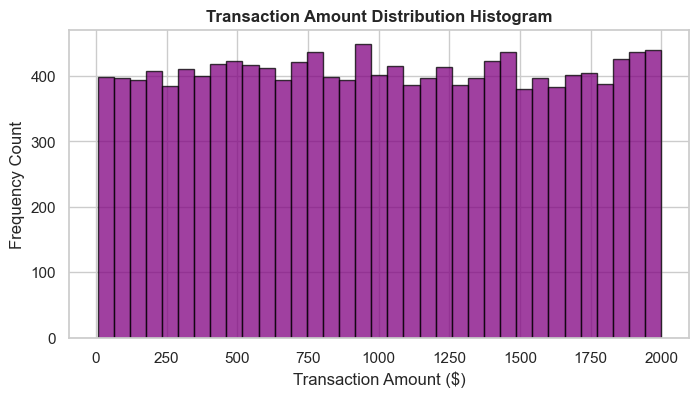

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['transaction_amount'], bins=35, color='purple', alpha=0.75, edgecolor='black')
ax.set_title('Transaction Amount Distribution Histogram', fontsize=12, fontweight='bold')
ax.set_xlabel('Transaction Amount ($)')
ax.set_ylabel('Frequency Count')
plt.show()

### Error Bars: `ax.errorbar(x, y, yerr=...)`
**Explanation**: Renders metric points with standard deviation uncertainty error bars across card types.

**Syntax**: `ax.errorbar(cards, means, yerr=stds, fmt='o')`

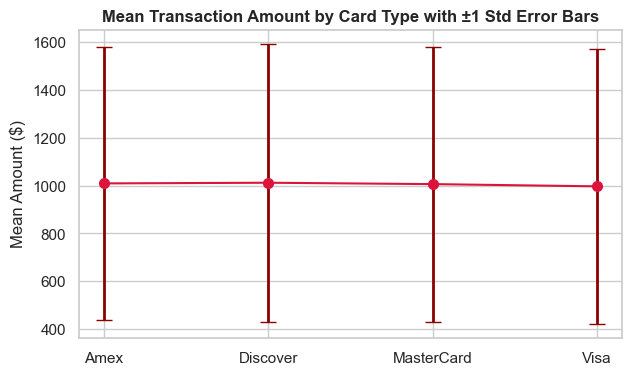

In [8]:
card_stats = df.groupby('card_type')['transaction_amount'].agg(['mean', 'std'])
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(card_stats.index, card_stats['mean'], yerr=card_stats['std'], fmt='o-', capsize=6, color='crimson', ecolor='darkred', elinewidth=2, markersize=7)
ax.set_title('Mean Transaction Amount by Card Type with ±1 Std Error Bars', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Amount ($)')
plt.show()

### Axis Labels: `ax.set_xlabel()` & `ax.set_ylabel()`
**Explanation**: Sets descriptive axis titles with font sizing, coloring, and padding.

**Syntax**: `ax.set_xlabel('Account Age (Months)', fontsize=12)`

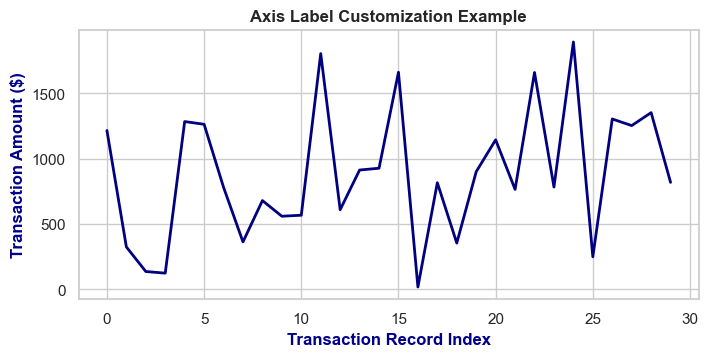

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(df['transaction_amount'].head(30), color='navy', lw=2)
ax.set_xlabel('Transaction Record Index', fontsize=12, fontweight='bold', color='darkblue')
ax.set_ylabel('Transaction Amount ($)', fontsize=12, fontweight='bold', color='darkblue')
ax.set_title('Axis Label Customization Example', fontsize=12, fontweight='bold')
plt.show()

### Chart Title: `ax.set_title()`
**Explanation**: Sets primary title header for the visual coordinate plane.

**Syntax**: `ax.set_title('Transaction Risk Distribution', fontsize=14)`

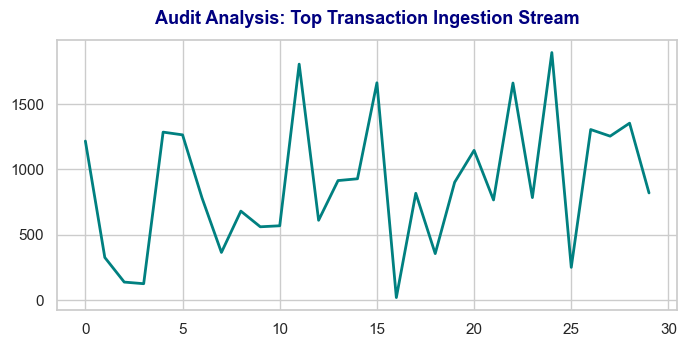

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(df['transaction_amount'].head(30), color='teal', lw=2)
ax.set_title('Audit Analysis: Top Transaction Ingestion Stream', fontsize=13, fontweight='bold', color='navy', pad=12)
plt.show()

### Axis Limits: `ax.set_xlim()` & `ax.set_ylim()`
**Explanation**: Restricts visible coordinate range boundaries.

**Syntax**: `ax.set_xlim(0, 100)` / `ax.set_ylim(0, 2000)`

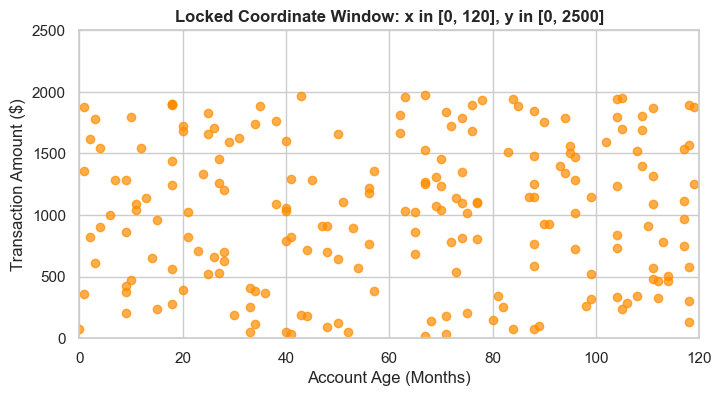

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df['account_age_months'].head(200), df['transaction_amount'].head(200), color='darkorange', alpha=0.7)
ax.set_xlim(0, 120)
ax.set_ylim(0, 2500)
ax.set_title('Locked Coordinate Window: x in [0, 120], y in [0, 2500]', fontsize=12, fontweight='bold')
ax.set_xlabel('Account Age (Months)')
ax.set_ylabel('Transaction Amount ($)')
plt.show()

### Gridlines: `ax.grid(True)`
**Explanation**: Overlays background guide grid lines for enhanced readability.

**Syntax**: `ax.grid(True, linestyle='--', alpha=0.7)`

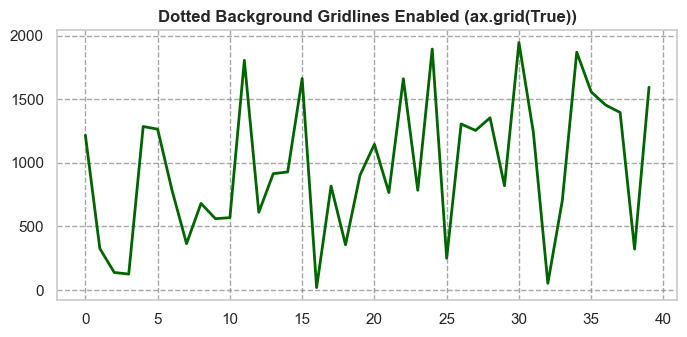

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(df['transaction_amount'].head(40), color='darkgreen', lw=2)
ax.grid(True, linestyle='--', alpha=0.7, color='gray')
ax.set_title('Dotted Background Gridlines Enabled (ax.grid(True))', fontsize=12, fontweight='bold')
plt.show()

### Legends: `ax.legend()`
**Explanation**: Displays visual key mapping line/point labels to series colors.

**Syntax**: `ax.legend(loc='upper right')`

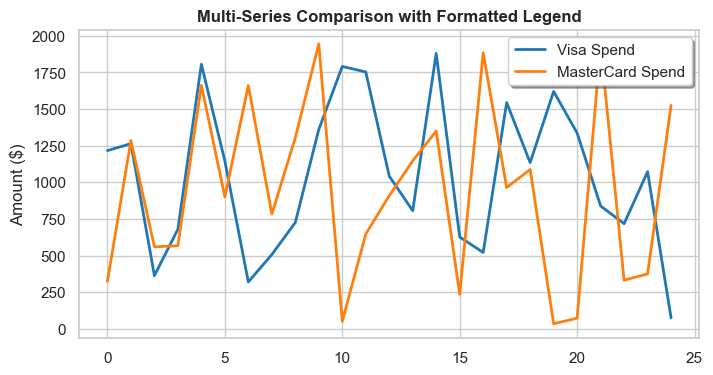

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df[df['card_type']=='Visa']['transaction_amount'].head(25).values, label='Visa Spend', color='#1f77b4', lw=2)
ax.plot(df[df['card_type']=='MasterCard']['transaction_amount'].head(25).values, label='MasterCard Spend', color='#ff7f0e', lw=2)
ax.legend(loc='upper right', frameon=True, shadow=True)
ax.set_title('Multi-Series Comparison with Formatted Legend', fontsize=12, fontweight='bold')
ax.set_ylabel('Amount ($)')
plt.show()

### Output Persistence: `fig.savefig()`
**Explanation**: Exports static publication-ready vector/raster graphics with DPI resolution control.

**Syntax**: `fig.savefig('plot.png', dpi=300, bbox_inches='tight')`

Exported to scratch/matplotlib_export.png. File size: 46892 bytes


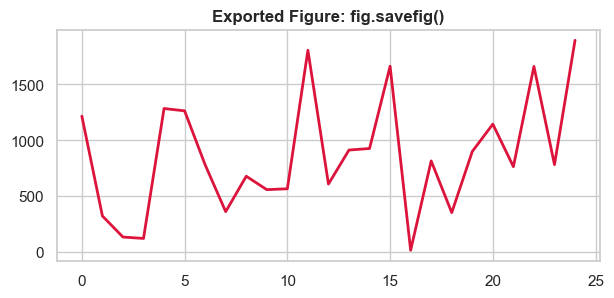

In [14]:
os.makedirs('scratch', exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(df['transaction_amount'].head(25), color='crimson', lw=2)
ax.set_title('Exported Figure: fig.savefig()', fontsize=12, fontweight='bold')
fig.savefig('scratch/matplotlib_export.png', dpi=150, bbox_inches='tight')
plt.show()
print('Exported to scratch/matplotlib_export.png. File size:', os.path.getsize('scratch/matplotlib_export.png'), 'bytes')

## Section: Senior Fintech Interview Scenarios (5+ Years Experience)

### Q1: Object-Oriented vs State-Based (pyplot) Matplotlib API
**Explanation**: Explain why the Object-Oriented API (`fig, ax = plt.subplots()`) is preferred for multi-threaded production pipelines over stateful `plt.plot()`.

**Syntax**: `fig, ax = plt.subplots()` vs `plt.plot()`

In [15]:
print('OO API: Explicitly manages Figure and Axes objects preventing global state collisions across concurrent threads.')

OO API: Explicitly manages Figure and Axes objects preventing global state collisions across concurrent threads.
